In [6]:
import sys
from pathlib import Path

# Add the project root to the Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

In [7]:
import pandas as pd
from src.data_loader import load_data
from src.analysis import normalize_timestamps, plot_news_by_day
from nltk.sentiment import SentimentIntensityAnalyzer
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import nltk

In [8]:
# Load news data
news = pd.read_csv('../../data/news_raw_data.csv')
news_df = pd.DataFrame(news)
news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [ ]:
meta_news_df = news_df[news_df['stock'] == 'META']
meta_news_df.head()

,Unnamed: 0,headline,url,publisher,date,stock


In [24]:
# as no article is found for META, we will use the news data for all instead
meta_news_df = news_df.copy()

In [25]:
# Load META stock data
meta_df = load_data(filepath='../../data/finance-data/META.csv')
meta_df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400.0
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700.0
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600.0
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000.0
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200.0


### **Date Alignment**

In [26]:
# Call normalize_timestamps with meta_news_df and stock_df
normalized_news = normalize_timestamps(
    stock_df=meta_df.reset_index().copy(),
    news_df=meta_news_df.copy(),
    sticker='META',
    news_date_col='date',
    stock_date_col='Date'
)
normalized_news.head()


News timestamps after timezone normalization:
0   2020-06-05 14:30:54
1   2020-06-03 14:45:20
2   2020-05-26 08:30:07
3   2020-05-22 16:45:06
4   2020-05-22 15:38:59
Name: date, dtype: datetime64[ns]

META Stock timestamps after timezone normalization:
0   2012-05-18
1   2012-05-21
2   2012-05-22
3   2012-05-23
4   2012-05-24
Name: Date, dtype: datetime64[ns]


,Unnamed: 0,headline,url,publisher,date,stock,trading_date
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 14:30:54,A,2020-06-05
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 14:45:20,A,2020-06-03
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 08:30:07,A,2020-05-26
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 16:45:06,A,2020-05-22
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 15:38:59,A,2020-05-22


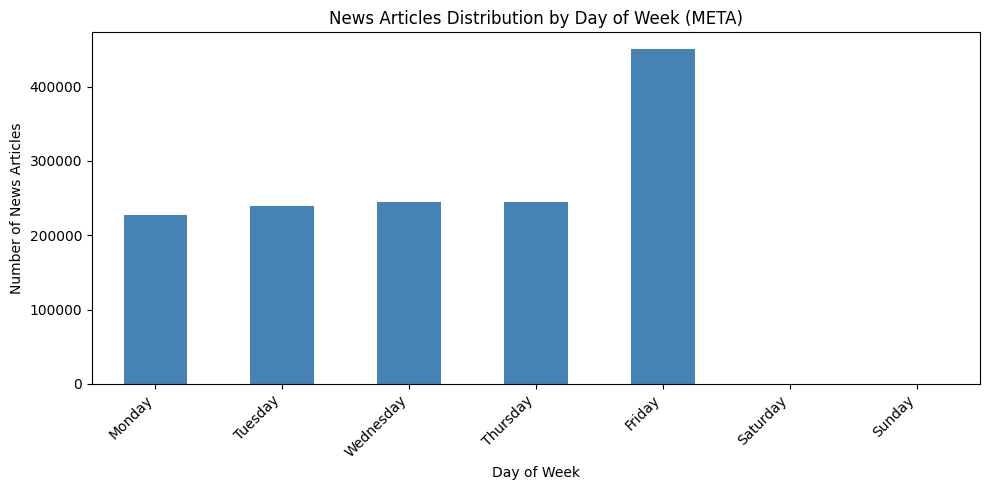

In [27]:
plot_news_by_day(normalized_news, 'META')

### **Sentiment Analysis**

In [28]:
nltk.download('vader_lexicon')

# Initialize the analyzer
sia = SentimentIntensityAnalyzer()

# Apply VADER to get the 'compound' score for each headline
normalized_news['sentiment_score'] = normalized_news['headline'].apply(lambda x: sia.polarity_scores(x)['compound'])


normalized_news[['headline', 'sentiment_score']].head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\teMelkishi\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,headline,sentiment_score
0,Stocks That Hit 52-Week Highs On Friday,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,0.000
2,71 Biggest Movers From Friday,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,0.000
4,B of A Securities Maintains Neutral on Agilent...,0.296


In [29]:
# Calculate daily percentage return: (Close_t - Close_t-1) / Close_t-1 * 100
meta_df['daily_return'] = meta_df['Close'].pct_change() * 100

# Ensure the index is in datetime format and keep only the date part
meta_df.index = pd.to_datetime(meta_df.index).date

meta_df[['Close', 'daily_return']].head()

,Close,daily_return
2012-05-18,37.995762,NaN
2012-05-21,33.821495,-10.986138
2012-05-22,30.810066,-8.903890
2012-05-23,31.803938,3.225802
2012-05-24,32.827625,3.218744


### **Aggregate and Correlate**

In [30]:
# Average daily sentiment score
daily_sentiment = (
    normalized_news
    .groupby('trading_date', as_index=False)['sentiment_score']
    .mean()
    .rename(columns={'sentiment_score': 'avg_sentiment'})
)

# Merge daily sentiment with daily stock return
meta_df_reset = meta_df.reset_index()
if 'index' in meta_df_reset.columns and 'Date' not in meta_df_reset.columns:
    meta_df_reset = meta_df_reset.rename(columns={'index': 'Date'})

daily_sentiment['trading_date'] = pd.to_datetime(daily_sentiment['trading_date'])
meta_df_reset['Date'] = pd.to_datetime(meta_df_reset['Date'])

merged_data = daily_sentiment.merge(
    meta_df_reset[['Date', 'daily_return']],
    left_on='trading_date',
    right_on='Date',
    how='inner'
)

merged_data.head()

,trading_date,avg_sentiment,Date,daily_return
0,2012-05-18,0.059973,2012-05-18,NaN
1,2012-05-21,0.045001,2012-05-21,-10.986138
2,2012-05-22,0.075884,2012-05-22,-8.903890
3,2012-05-23,0.084813,2012-05-23,3.225802
4,2012-05-24,0.055747,2012-05-24,3.218744


In [31]:
# Calculate the Pearson correlation coefficient between average daily sentiment scores and daily stock returns
correlation = merged_data['avg_sentiment'].corr(merged_data['daily_return'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

Pearson Correlation Coefficient: 0.1503


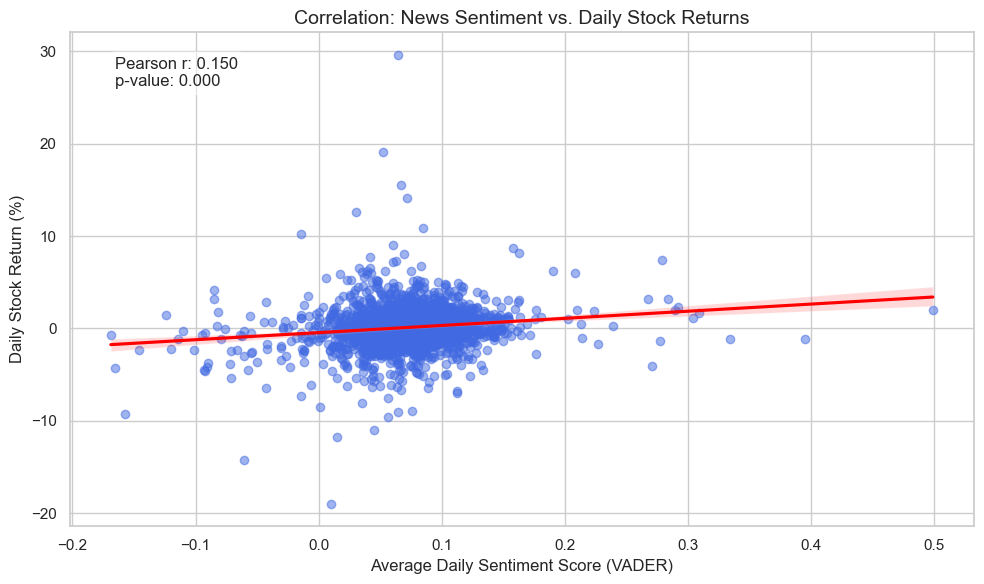

In [32]:


# Use the merged dataset created earlier
plot_data = merged_data.dropna(subset=['avg_sentiment', 'daily_return'])

# Pearson correlation + p-value
corr_val, p_val = pearsonr(plot_data['avg_sentiment'], plot_data['daily_return'])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.regplot(
    x='avg_sentiment',
    y='daily_return',
    data=plot_data,
    scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
    line_kws={'color': 'red', 'label': 'Regression Line'}
)

plt.text(
    0.05, 0.95,
    f'Pearson r: {corr_val:.3f}\np-value: {p_val:.3f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5)
)

plt.title('Correlation: News Sentiment vs. Daily Stock Returns', fontsize=14)
plt.xlabel('Average Daily Sentiment Score (VADER)', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)
plt.tight_layout()
plt.show()


posx and posy should be finite values
posx and posy should be finite values


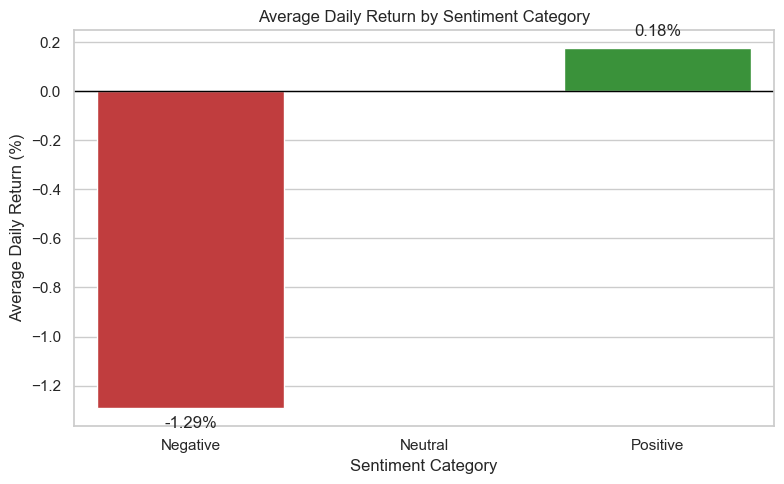

In [33]:
# Classify each day by average sentiment score
classified_data = merged_data.copy()
classified_data['sentiment_category'] = pd.cut(
    classified_data['avg_sentiment'],
    bins=[-float('inf'), -1e-6, 1e-6, float('inf')],
    labels=['Negative', 'Neutral', 'Positive']
)

# Compute average daily return per sentiment category
avg_return_by_sentiment = (
    classified_data
    .groupby('sentiment_category', observed=False)['daily_return']
    .mean()
    .reindex(['Negative', 'Neutral', 'Positive'])
)

# Plot as bar chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=avg_return_by_sentiment.index,
    y=avg_return_by_sentiment.values,
    palette=['#d62728', '#7f7f7f', '#2ca02c']
)

ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Daily Return by Sentiment Category')
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Average Daily Return (%)')

for i, v in enumerate(avg_return_by_sentiment.values):
    ax.text(i, v + (0.05 if v >= 0 else -0.08), f'{v:.2f}%', ha='center')

plt.tight_layout()
plt.show()